# Ranking Pollution Days; Combined Facility Footprint

---

We have two industrial facilities, each of which has a model that predicts how much pollution it's releasing into the air every day. That model outputs one grid per facility per day, saved as a TIF.

The goal is: combine all the facilities' grids into one, add up all the squares, and use that total to rank every day from worst to best.

For each day we:
1. Compute the shared canvas dimensions from both facilities' bounds (done once at startup)
2. Place each facility's array into its correct position on the shared canvas
3. Sum the two placed arrays
4. Compute the **regional sum** (total pollution across all cells) for that day
5. Rank all days by that total and flag the top X% for notification

## Setup

Just loading the Python libraries we need. rasterio is the one that knows how to read TIF files. 
* numpy handles the math on arrays. 
* pandas handles tables. 
* matplotlib makes the charts.

In [1]:
# pip install rasterio numpy pandas matplotlib

import os
import glob
import warnings
import numpy as np
import pandas as pd
import rasterio
from rasterio.transform import from_bounds
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

warnings.filterwarnings('ignore')
print('imports OK')

imports OK


## Configuration

FACILITY_DIRS = tells the notebook where to find each facility's TIF files (the file path)

TOP_FRACTION = 0.10, so flag the worst 10% of days for notification.

In [ ]:
# ── SETTINGS ──────────────────────────────────────────────────────────────────

# change these to your local paths where the TIFs are stored!

FACILITY_DIRS = {
    'facility_A': '/Users/clairevlases/Desktop/mhci/create-lab/clairton',   # ← update these paths
    'facility_B': '/Users/clairevlases/Desktop/mhci/create-lab/edgar_thomson',
    'facility_C': '/Users/clairevlases/Desktop/create/irvin',
}


NODATA_VAL = 0.0

# Top X% of days will be flagged for notification.
# 0.10 = top 10%, 0.15 = top 15%, etc.
# Change this and re-run from the ranking cell — no need to reload the TIFs.
TOP_FRACTION = 0.10

# ──────────────────────────────────────────────────────────────────────────────

all_dates = set()
for name, folder in FACILITY_DIRS.items():
    files = glob.glob(os.path.join(folder, '*.tif'))
    dates = {os.path.basename(f).replace('.tif', '') for f in files}
    print(f'{name}: {len(files)} files  ({min(dates)} → {max(dates)})')
    all_dates |= dates

all_dates = sorted(all_dates)
print(f'\nTotal unique dates: {len(all_dates)}')

facility_A: 366 files  (20240101 → 20241231)
facility_B: 366 files  (20240101 → 20241231)
facility_C: 366 files  (20240101 → 20241231)

Total unique dates: 366


## Build the shared canvas

The grids are (unfortunately) not exactly the same... Both have the same pixel size, but they're not perfectly lined up on top of each other.

We read one representative file from each facility to get their bounds, compute the union bounding box, then calculate where each facility's grid sits within that shared space as a pixel offset.

Since pixel sizes are identical, the offset is always a whole number of pixels — so placing each array is just `canvas[row_offset:row_offset+601, col_offset:col_offset+601] += data`.


In [3]:
def get_grid_info(folder):
    files = sorted(glob.glob(os.path.join(folder, '*.tif')))
    if not files:
        raise FileNotFoundError(f'No TIF files found in {folder}')
    with rasterio.open(files[0]) as src:
        return {
            'crs':    src.crs,
            'width':  src.width,
            'height': src.height,
            'bounds': src.bounds,
            'res_x':  src.transform.a,
            'res_y':  abs(src.transform.e),
        }

grid_infos = {}
for name, folder in FACILITY_DIRS.items():
    info = get_grid_info(folder)
    grid_infos[name] = info
    print(f'{name}:')
    print(f'  Shape:  {info["height"]} × {info["width"]}')
    print(f'  Bounds: {info["bounds"]}')
    print()

# All facilities must share the same CRS and pixel size
ref = list(grid_infos.values())[0]
for name, info in list(grid_infos.items())[1:]:
    assert str(info['crs'])  == str(ref['crs']),             f'{name}: CRS mismatch'
    assert abs(info['res_x'] - ref['res_x']) < 1e-8,        f'{name}: x resolution mismatch'
    assert abs(info['res_y'] - ref['res_y']) < 1e-8,        f'{name}: y resolution mismatch'
print('✓ CRS and pixel size match across all facilities')

# Union bounding box
res_x = ref['res_x']
res_y = ref['res_y']
shared_left   = min(i['bounds'].left   for i in grid_infos.values())
shared_right  = max(i['bounds'].right  for i in grid_infos.values())
shared_bottom = min(i['bounds'].bottom for i in grid_infos.values())
shared_top    = max(i['bounds'].top    for i in grid_infos.values())

shared_width  = int(np.ceil((shared_right - shared_left)  / res_x))
shared_height = int(np.ceil((shared_top   - shared_bottom) / res_y))

print(f'\nShared canvas: {shared_height} rows × {shared_width} cols')
print(f'Lon: {shared_left:.4f} → {shared_right:.4f}')
print(f'Lat: {shared_bottom:.4f} → {shared_top:.4f}')

# Pixel offset of each facility's top-left corner within the shared canvas
# (rasterio's origin is top-left, y increases downward in pixel space)
offsets = {}
for name, info in grid_infos.items():
    col_offset = round((info['bounds'].left - shared_left)  / res_x)
    row_offset = round((shared_top - info['bounds'].top)    / res_y)
    offsets[name] = (row_offset, col_offset)
    print(f'{name}: row_offset={row_offset}, col_offset={col_offset}')

facility_A:
  Shape:  601 × 601
  Bounds: BoundingBox(left=-80.85333251953125, bottom=39.393333435058594, right=-78.85333247110248, top=41.39333348348737)

facility_B:
  Shape:  601 × 601
  Bounds: BoundingBox(left=-80.88333129882812, bottom=39.310001373291016, right=-78.88333125039935, top=41.31000142171979)

facility_C:
  Shape:  601 × 601
  Bounds: BoundingBox(left=-80.90333557128906, bottom=39.32666778564453, right=-78.90333552286029, top=41.326667834073305)

✓ CRS and pixel size match across all facilities

Shared canvas: 627 rows × 617 cols
Lon: -80.9033 → -78.8533
Lat: 39.3100 → 41.3933
facility_A: row_offset=0, col_offset=15
facility_B: row_offset=25, col_offset=6
facility_C: row_offset=20, col_offset=0


## Combine facilities for a given day

For each day, allocate a blank shared canvas and stamp each facility's array into its correct position. Where the two plumes overlap, values are summed. Where only one facility reaches a pixel, the other contributes zero.

In [ ]:
def combine_facilities(date_str, facility_dirs, offsets, grid_infos,
                       shared_height, shared_width, nodata=0.0):
    """
    Load each facility's raster for date_str, place it onto the shared canvas
    at its correct pixel offset, and sum.

    The pixel sizes are identical, so placement is a
    simple integer array slice.

    Returns
    -------
    combined : np.ndarray (shared_height × shared_width)
    sources  : list of facility names that had data for this date
    """
    canvas = np.zeros((shared_height, shared_width), dtype=np.float32)
    sources = []

    for name, folder in facility_dirs.items():
        fpath = os.path.join(folder, f'{date_str}.tif')
        if not os.path.exists(fpath):
            continue

        with rasterio.open(fpath) as src:
            data = src.read(1).astype(np.float32)

        data[data == nodata] = 0.0

        row_off, col_off = offsets[name]
        h, w = grid_infos[name]['height'], grid_infos[name]['width']
        canvas[row_off:row_off + h, col_off:col_off + w] += data
        sources.append(name)

    return canvas, sources


# Quick test
test_date = all_dates[0]
arr, sources = combine_facilities(
    test_date, FACILITY_DIRS, offsets, grid_infos, shared_height, shared_width
)
print(f'Test: {test_date}  |  facilities: {sources}')
print(f'Canvas shape: {arr.shape}  |  non-zero pixels: {(arr > 0).sum():,}')
print(f'Sum: {arr.sum():.2f}  |  Max: {arr.max():.4f}')

Test: 20240101  |  facilities: ['facility_A', 'facility_B', 'facility_C']
Canvas shape: (627, 617)  |  non-zero pixels: 47,525
Sum: 6802.86  |  Max: 106.7005


### Visualizing the combined footprint

Making sure it's working! (visual test)

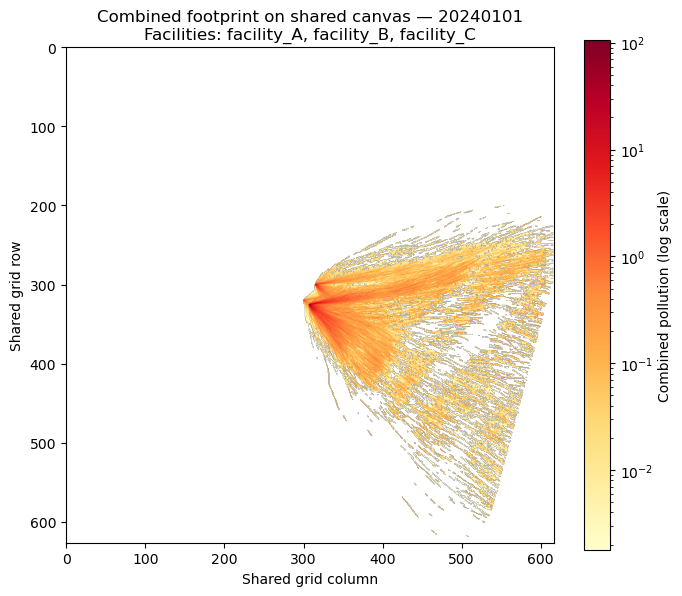

In [5]:
display = arr.copy().astype(float)
display[display == 0] = np.nan

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(
    display, origin='upper', cmap='YlOrRd',
    norm=mcolors.LogNorm(
        vmin=max(np.nanpercentile(display, 5), 1e-4),
        vmax=np.nanmax(display)
    )
)
plt.colorbar(im, ax=ax, label='Combined pollution (log scale)')
ax.set_title(f'Combined footprint on shared canvas — {test_date}\nFacilities: {", ".join(sources)}')
ax.set_xlabel('Shared grid column'); ax.set_ylabel('Shared grid row')
plt.tight_layout()
plt.savefig('combined_footprint_example.png', dpi=120, bbox_inches='tight')
plt.show()

## Compute regional sum for every day and rank them

regional_sum: the total pollution across every grid cell on that day, from all the facilities combined. This is the number used for ranking. Think of it as the "total pollution mass" floating over the region. It goes up when the plume is either more intense, covers a wider area, or both.

regional_max: the single highest value found in any one grid cell that day. This is useful as a diagnostic alongside the sum. For example if two days have similar regional_sum values but very different regional_max values, that tells you something about the shape of the pollution. A high max with a moderate sum means the pollution was concentrated in a small hot zone near the plant. A moderate max with a high sum means it was spread widely across the region.

nonzero_pixels: how many grid cells had any pollution at all that day (i.e. the plume reached them). This is essentially the footprint size. A day with 50,000 nonzero pixels had a much wider-spreading plume than a day with 10,000, even if the sums are similar.

In [ ]:
records = []

for date_str in all_dates:
    combined, sources = combine_facilities(
        date_str, FACILITY_DIRS, offsets, grid_infos, shared_height, shared_width
    )
    if not sources:
        print(f'  {date_str}: no data!')
        continue

    records.append({
        'date':           pd.to_datetime(date_str, format='%Y%m%d'),
        'date_str':       date_str,
        'regional_sum':   float(combined.sum()),
        'regional_max':   float(combined.max()),
        'nonzero_pixels': int((combined > 0).sum()),
        'facilities':     ', '.join(sources),
        'n_facilities':   len(sources),
    })

daily = pd.DataFrame(records).sort_values('date').reset_index(drop=True)

# Rank 1 = worst day
daily['rank']       = daily['regional_sum'].rank(ascending=False, method='min').astype(int)
daily['percentile'] = daily['regional_sum'].rank(pct=True)

print(f'Processed {len(daily)} days\n')
print('All days, worst → best:')
print(
    daily.sort_values('rank')[
        ['rank', 'date_str', 'regional_sum', 'regional_max', 'nonzero_pixels']
    ].to_string(index=False)
)

Processed 366 days

All days, worst → best:
 rank date_str  regional_sum  regional_max  nonzero_pixels
    1 20240207  44038.054688    368.194611           75629
    2 20241018  41094.132812    343.717194           68578
    3 20241019  40632.414062    283.252106           92428
    4 20241003  35691.218750    571.893188          104109
    5 20241027  35489.500000    425.573730           96740
    6 20240203  35356.308594    352.353943           84356
    7 20240206  33308.792969    264.333557           98363
    8 20241005  29250.957031    208.878952          150709
    9 20241028  28066.025391    335.369690           89627
   10 20241225  26503.750000    297.254730           95964
   11 20240823  26427.125000    214.475388           94565
   12 20240822  25932.724609    297.710999          108847
   13 20240919  25867.361328    183.362396           79137
   14 20240204  25519.677734    318.686951           80715
   15 20240824  25126.638672    301.812469           73333
   16 202411

## Apply notification threshold

Change `TOP_FRACTION` in the config cell and re-run from here if changing it from 10%

In [7]:
threshold = daily['regional_sum'].quantile(1 - TOP_FRACTION)

daily['notify']           = daily['regional_sum'] >= threshold
daily['pct_of_threshold'] = daily['regional_sum'] / threshold

n_notify = daily['notify'].sum()
n_days   = len(daily)

print(f'TOP_FRACTION:    {TOP_FRACTION*100:.0f}%')
print(f'Threshold value: {threshold:.2f}')
print(f'Days to notify:  {n_notify} / {n_days}  ({100*n_notify/n_days:.1f}%)')
print()
print('Notification days:')
print(
    daily[daily['notify']].sort_values('rank')[
        ['rank', 'date_str', 'regional_sum', 'pct_of_threshold', 'nonzero_pixels']
    ].to_string(index=False)
)

TOP_FRACTION:    10%
Threshold value: 20721.66
Days to notify:  37 / 366  (10.1%)

Notification days:
 rank date_str  regional_sum  pct_of_threshold  nonzero_pixels
    1 20240207  44038.054688          2.125219           75629
    2 20241018  41094.132812          1.983149           68578
    3 20241019  40632.414062          1.960867           92428
    4 20241003  35691.218750          1.722411          104109
    5 20241027  35489.500000          1.712677           96740
    6 20240203  35356.308594          1.706249           84356
    7 20240206  33308.792969          1.607439           98363
    8 20241005  29250.957031          1.411613          150709
    9 20241028  28066.025391          1.354430           89627
   10 20241225  26503.750000          1.279036           95964
   11 20240823  26427.125000          1.275338           94565
   12 20240822  25932.724609          1.251479          108847
   13 20240919  25867.361328          1.248325           79137
   14 20240204  

## Visualizations

### Timeline: all days, ranked

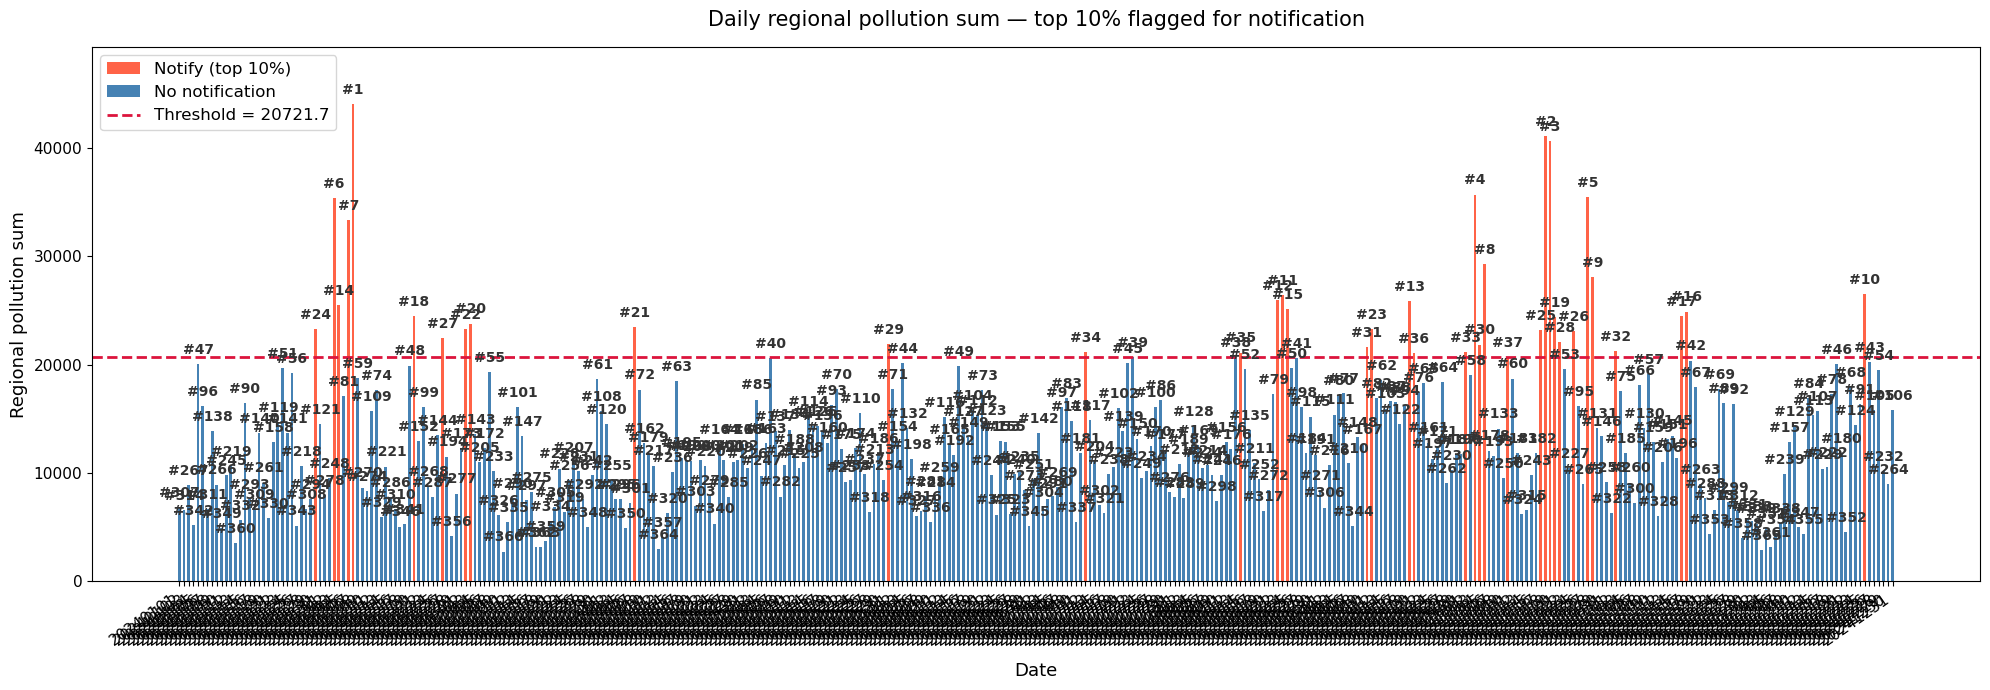

In [10]:
fig, ax = plt.subplots(figsize=(20, 7))

colors = ['tomato' if n else 'steelblue' for n in daily['notify']]
bars = ax.bar(daily['date_str'], daily['regional_sum'], color=colors, width=0.6)

ax.axhline(threshold, color='crimson', linestyle='--', linewidth=2,
           label=f'Top {TOP_FRACTION*100:.0f}% threshold = {threshold:.1f}')

# Rank labels above each bar
for _, row in daily.iterrows():
    ax.text(row['date_str'], row['regional_sum'] + daily['regional_sum'].max() * 0.015,
            f'#{int(row["rank"])}', ha='center', va='bottom', fontsize=10, 
            fontweight='bold', color='#333')

legend_elements = [
    Patch(facecolor='tomato',    label=f'Notify (top {TOP_FRACTION*100:.0f}%)'),
    Patch(facecolor='steelblue', label='No notification'),
    plt.Line2D([0],[0], color='crimson', linestyle='--', linewidth=2,
               label=f'Threshold = {threshold:.1f}')
]
ax.legend(handles=legend_elements, fontsize=12, loc='upper left')

# Dates on x-axis: diagonal and bigger
ax.set_xticks(range(len(daily)))
ax.set_xticklabels(daily['date_str'], rotation=35, ha='right', fontsize=11)

ax.set_xlabel('Date', fontsize=13, labelpad=10)
ax.set_ylabel('Regional pollution sum', fontsize=13)
ax.set_title(f'Daily regional pollution sum — top {TOP_FRACTION*100:.0f}% flagged for notification',
             fontsize=15, pad=15)

# Give the rank labels some breathing room at the top
ax.set_ylim(0, daily['regional_sum'].max() * 1.12)

ax.tick_params(axis='y', labelsize=11)
plt.tight_layout()
plt.savefig('daily_ranking_timeline.png', dpi=150, bbox_inches='tight')
plt.show()

a slightly cleaner graph....

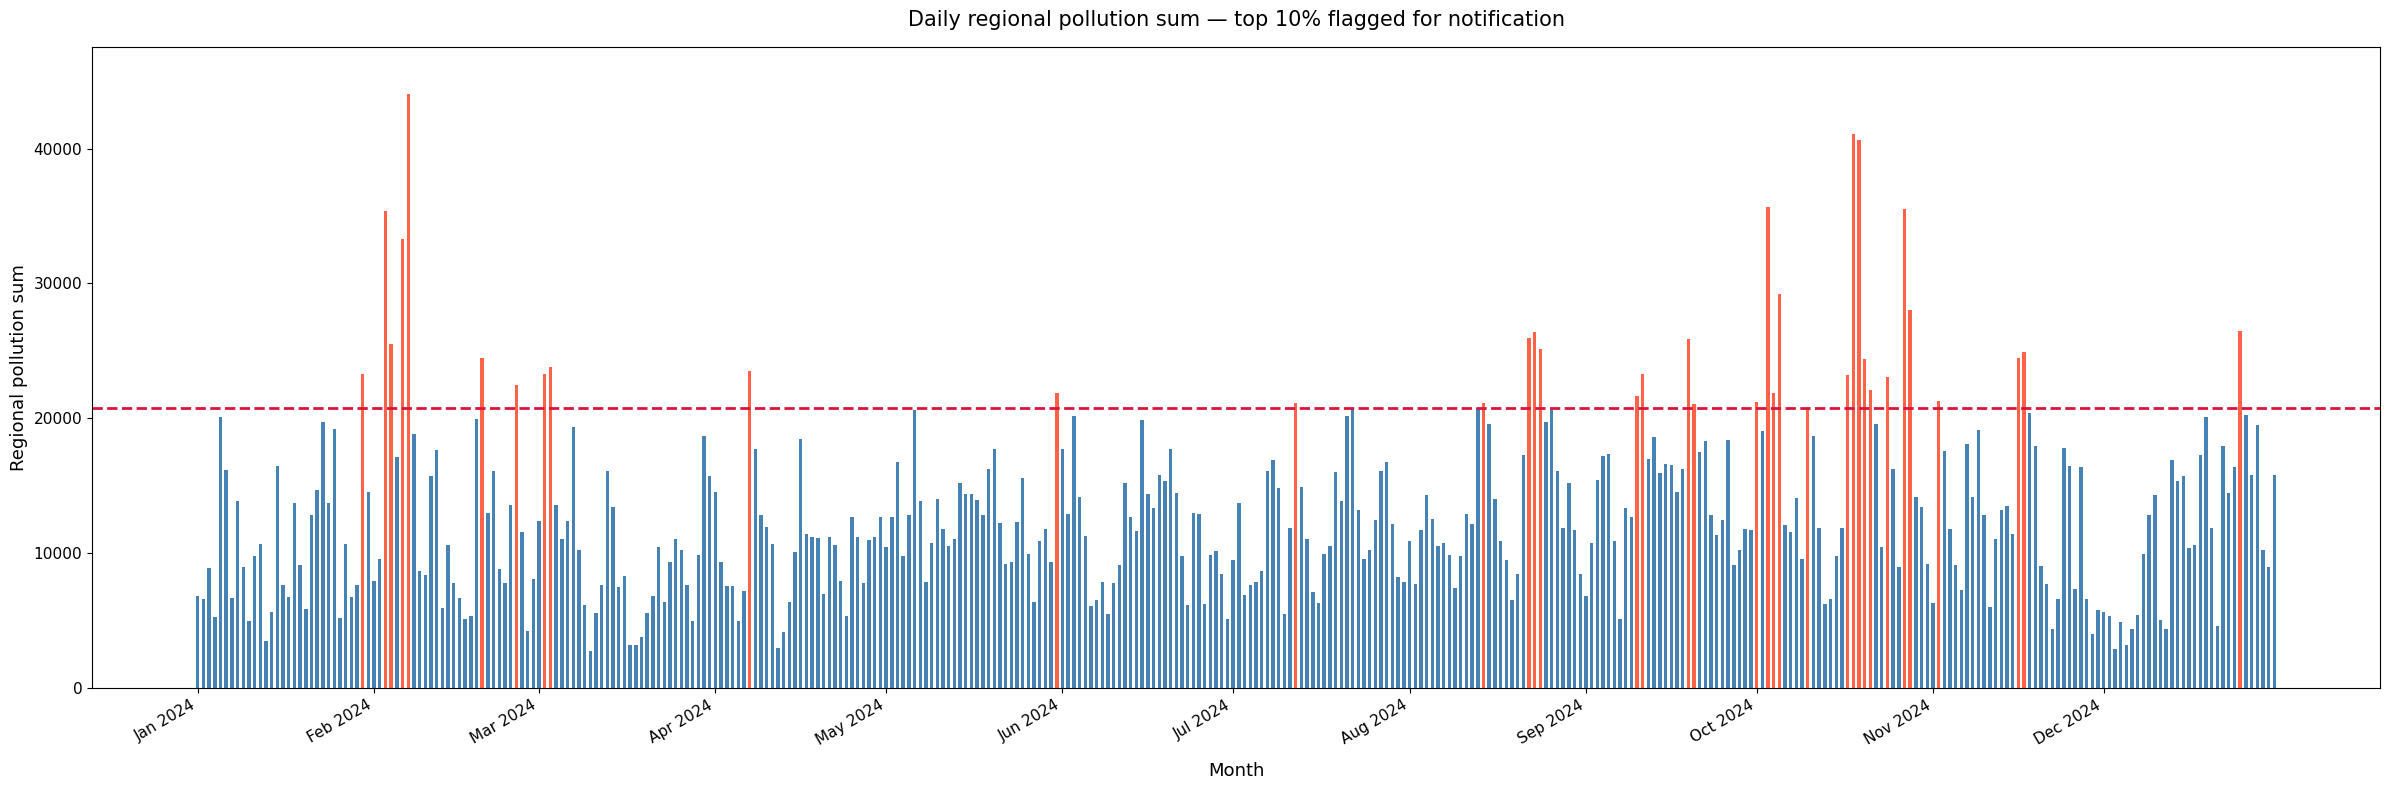

In [15]:
fig, ax = plt.subplots(figsize=(24, 8))

colors = ['tomato' if n else 'steelblue' for n in daily['notify']]
bars = ax.bar(daily['date_str'], daily['regional_sum'], color=colors, width=0.6)

ax.axhline(threshold, color='crimson', linestyle='--', linewidth=2,
           label=f'Top {TOP_FRACTION*100:.0f}% threshold = {threshold:.1f}')


# Show only month labels: find the first bar of each month and label it
month_ticks = []
month_labels = []
seen_months = set()
for i, date_str in enumerate(daily['date_str']):
    month = date_str[:7]          # e.g. '2024-01' — but date_str is 'YYYYMMDD'
    month = date_str[:6]          # '202401'
    if month not in seen_months:
        seen_months.add(month)
        month_ticks.append(i)
        # Format as 'Jan 2024', 'Feb 2024', etc.
        dt = pd.to_datetime(date_str, format='%Y%m%d')
        month_labels.append(dt.strftime('%b %Y'))

ax.set_xticks(month_ticks)
ax.set_xticklabels(month_labels, rotation=30, ha='right', fontsize=11)

ax.set_xlabel('Month', fontsize=13, labelpad=10)
ax.set_ylabel('Regional pollution sum', fontsize=13)
ax.set_title(
    f'Daily regional pollution sum — top {TOP_FRACTION*100:.0f}% flagged for notification',
    fontsize=15, pad=15
)
ax.set_ylim(0, daily['regional_sum'].max() * 1.08)
ax.tick_params(axis='y', labelsize=11)

plt.tight_layout()
plt.savefig('daily_ranking_timeline.png', dpi=150, bbox_inches='tight')
plt.show()

# Notification Streaks / Gaps

Curious to see how often the user will get notified in a row (streak) and how long in between notifications (gap).


--> might want a "all-clear" notification when a streak ends rather than firing every single day of the streak

In [16]:
# Notification streak and gap analysis
notify_dates = daily.sort_values('date')['notify'].values
dates = daily.sort_values('date')['date_str'].values

streaks = []
gaps = []

current_streak = 0
current_gap = 0

for i, notified in enumerate(notify_dates):
    if notified:
        if current_gap > 0:
            gaps.append(current_gap)
        current_gap = 0
        current_streak += 1
    else:
        if current_streak > 0:
            streaks.append(current_streak)
        current_streak = 0
        current_gap += 1

# Catch trailing streak or gap
if current_streak > 0:
    streaks.append(current_streak)
if current_gap > 0:
    gaps.append(current_gap)

print(f'Total notification days: {notify_dates.sum()} / {len(notify_dates)}')
print()
print('--- STREAKS (consecutive notification days) ---')
print(f'  Number of streaks:      {len(streaks)}')
print(f'  Longest streak:         {max(streaks) if streaks else 0} days')
print(f'  Average streak length:  {np.mean(streaks):.1f} days' if streaks else '  No streaks')
print(f'  All streaks:            {sorted(streaks, reverse=True)}')
print()
print('--- GAPS (days between notifications) ---')
print(f'  Number of gaps:         {len(gaps)}')
print(f'  Longest gap:            {max(gaps) if gaps else 0} days')
print(f'  Average gap:            {np.mean(gaps):.1f} days' if gaps else '  No gaps')
print(f'  All gaps:               {sorted(gaps, reverse=True)}')

Total notification days: 37 / 366

--- STREAKS (consecutive notification days) ---
  Number of streaks:      22
  Longest streak:         5 days
  Average streak length:  1.7 days
  All streaks:            [5, 3, 3, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

--- GAPS (days between notifications) ---
  Number of gaps:         23
  Longest gap:            53 days
  Average gap:            14.3 days
  All gaps:               [53, 41, 37, 34, 32, 29, 16, 13, 12, 10, 7, 7, 6, 6, 5, 4, 4, 4, 3, 2, 2, 1, 1]


# What if the threshold was 15% instead?

In [17]:
for fraction in [0.10, 0.15]:
    threshold = daily['regional_sum'].quantile(1 - fraction)
    n = (daily['regional_sum'] >= threshold).sum()
    print(f'Top {fraction*100:.0f}%: threshold={threshold:.1f}, notify days={n}, ~{n*365/len(daily):.0f}/yr')

Top 10%: threshold=20721.7, notify days=37, ~37/yr
Top 15%: threshold=19236.8, notify days=55, ~55/yr


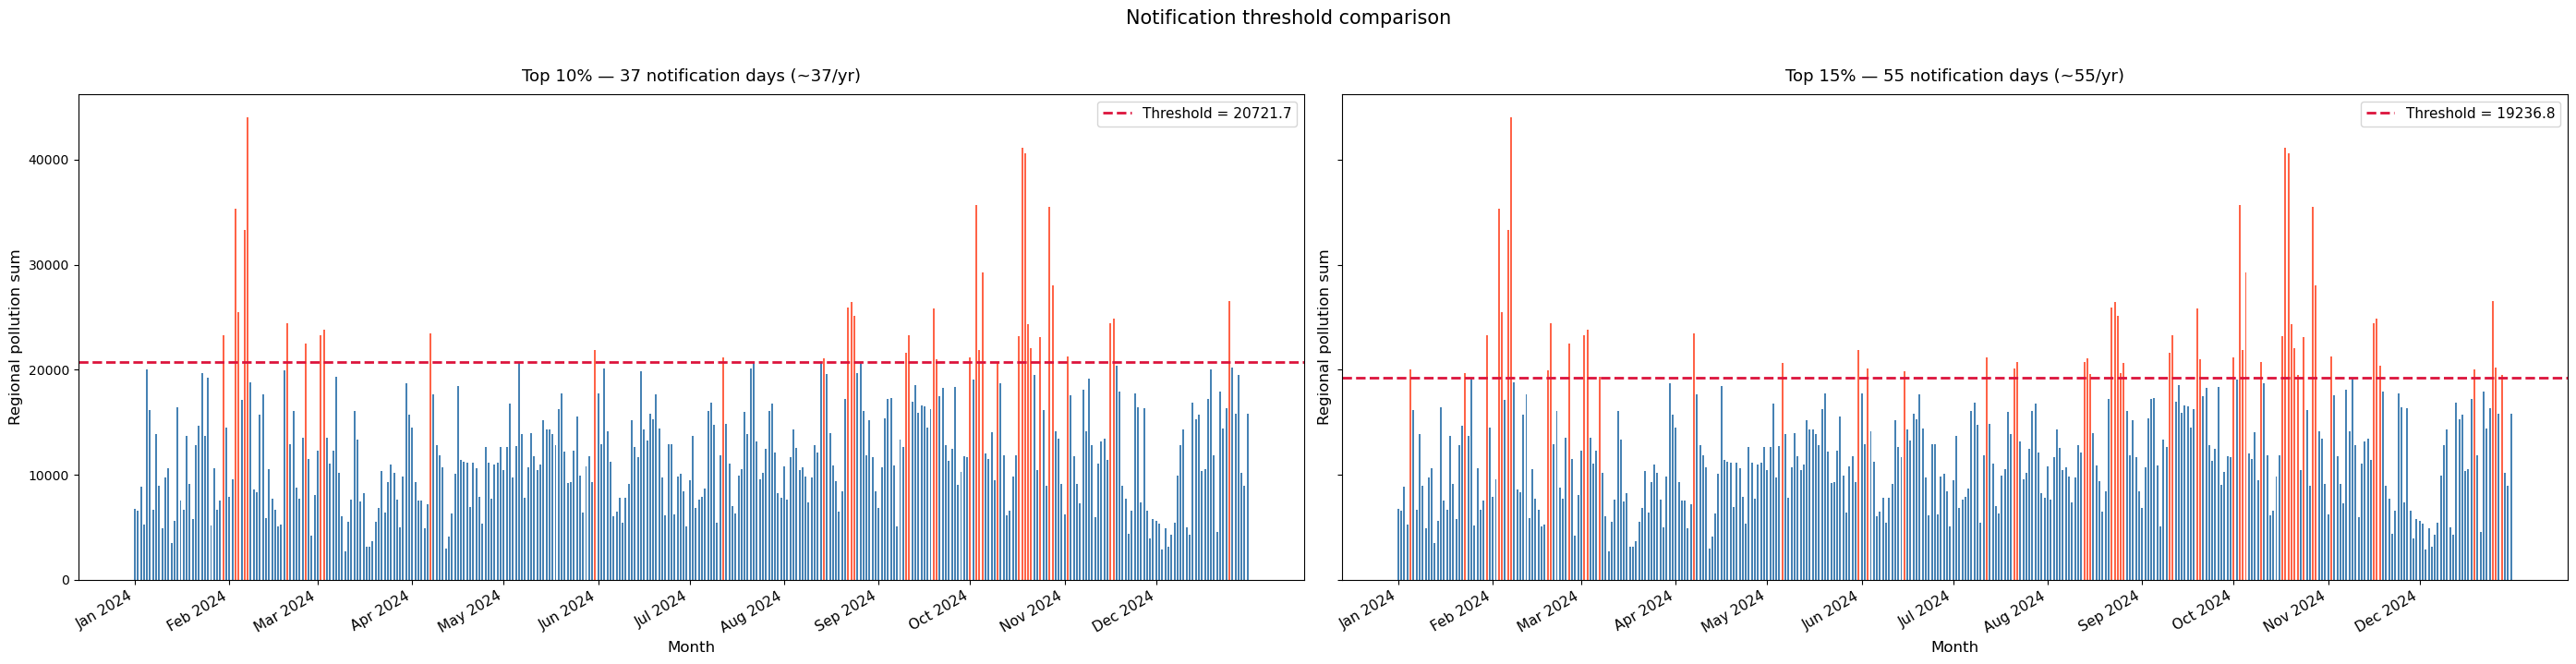

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(28, 7), sharey=True)

for ax, fraction in zip(axes, [0.10, 0.15]):
    threshold = daily['regional_sum'].quantile(1 - fraction)
    daily['notify'] = daily['regional_sum'] >= threshold

    colors = ['tomato' if n else 'steelblue' for n in daily['notify']]
    ax.bar(daily['date_str'], daily['regional_sum'], color=colors, width=0.6)
    ax.axhline(threshold, color='crimson', linestyle='--', linewidth=2,
               label=f'Threshold = {threshold:.1f}')

    seen_months = set()
    month_ticks, month_labels = [], []
    for i, date_str in enumerate(daily['date_str']):
        month = date_str[:6]
        if month not in seen_months:
            seen_months.add(month)
            month_ticks.append(i)
            month_labels.append(pd.to_datetime(date_str, format='%Y%m%d').strftime('%b %Y'))
    ax.set_xticks(month_ticks)
    ax.set_xticklabels(month_labels, rotation=30, ha='right', fontsize=11)

    n_notify = daily['notify'].sum()
    ax.set_title(f'Top {fraction*100:.0f}% — {n_notify} notification days (~{n_notify*365/len(daily):.0f}/yr)',
                 fontsize=13, pad=10)
    ax.set_xlabel('Month', fontsize=12)
    ax.set_ylabel('Regional pollution sum', fontsize=12)
    ax.legend(fontsize=11)

plt.suptitle('Notification threshold comparison', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('threshold_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Reset to whichever threshold you want to keep
TOP_FRACTION = 0.10
threshold = daily['regional_sum'].quantile(1 - TOP_FRACTION)
daily['notify'] = daily['regional_sum'] >= threshold


--- Top 10% ---
  Notification days:  37 / 366
  Longest streak:     5 days
  Average streak:     1.7 days
  Longest gap:        53 days
  Average gap:        14.3 days
  All streaks:        [5, 3, 3, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
  All gaps:           [53, 41, 37, 34, 32, 29, 16, 13, 12, 10, 7, 7, 6, 6, 5, 4, 4, 4, 3, 2, 2, 1, 1]

--- Top 15% ---
  Notification days:  55 / 366
  Longest streak:     6 days
  Average streak:     1.8 days
  Longest gap:        30 days
  Average gap:        9.7 days
  All streaks:        [6, 5, 3, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
  All gaps:           [30, 30, 28, 26, 24, 21, 17, 14, 13, 11, 11, 10, 8, 7, 6, 6, 6, 5, 5, 4, 4, 4, 4, 3, 3, 3, 2, 2, 1, 1, 1, 1]


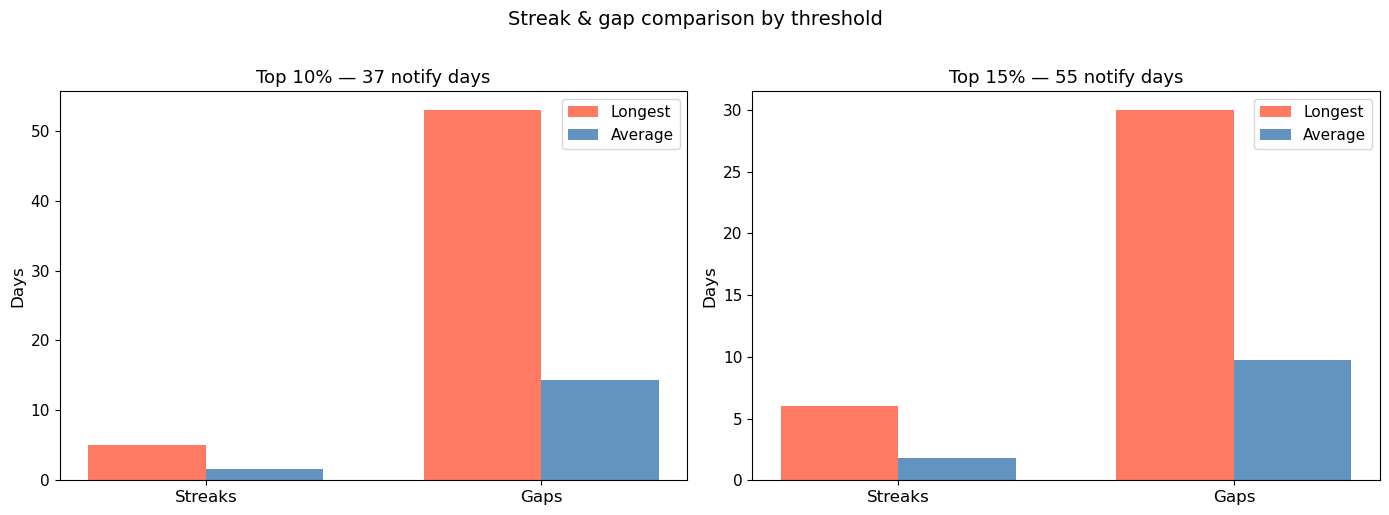

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, fraction in zip(axes, [0.10, 0.15]):
    threshold = daily['regional_sum'].quantile(1 - fraction)
    notify_vals = (daily.sort_values('date')['regional_sum'] >= threshold).values

    streaks, gaps = [], []
    current_streak, current_gap = 0, 0

    for notified in notify_vals:
        if notified:
            if current_gap > 0:
                gaps.append(current_gap)
            current_gap = 0
            current_streak += 1
        else:
            if current_streak > 0:
                streaks.append(current_streak)
            current_streak = 0
            current_gap += 1

    if current_streak > 0: streaks.append(current_streak)
    if current_gap > 0:    gaps.append(current_gap)

    print(f'\n--- Top {fraction*100:.0f}% ---')
    print(f'  Notification days:  {notify_vals.sum()} / {len(notify_vals)}')
    print(f'  Longest streak:     {max(streaks) if streaks else 0} days')
    print(f'  Average streak:     {np.mean(streaks):.1f} days' if streaks else '  No streaks')
    print(f'  Longest gap:        {max(gaps) if gaps else 0} days')
    print(f'  Average gap:        {np.mean(gaps):.1f} days' if gaps else '  No gaps')
    print(f'  All streaks:        {sorted(streaks, reverse=True)}')
    print(f'  All gaps:           {sorted(gaps, reverse=True)}')

    # Plot streak and gap distributions side by side as grouped bars
    categories = ['Streaks', 'Gaps']
    longest = [max(streaks) if streaks else 0, max(gaps) if gaps else 0]
    average = [np.mean(streaks) if streaks else 0, np.mean(gaps) if gaps else 0]

    x = np.arange(len(categories))
    width = 0.35
    ax.bar(x - width/2, longest, width, label='Longest', color='tomato', alpha=0.85)
    ax.bar(x + width/2, average, width, label='Average', color='steelblue', alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(categories, fontsize=12)
    ax.set_ylabel('Days', fontsize=12)
    ax.set_title(f'Top {fraction*100:.0f}% — {notify_vals.sum()} notify days', fontsize=13)
    ax.legend(fontsize=11)
    ax.tick_params(axis='y', labelsize=11)

plt.suptitle('Streak & gap comparison by threshold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('streak_gap_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Reset
TOP_FRACTION = 0.10
threshold = daily['regional_sum'].quantile(1 - TOP_FRACTION)
daily['notify'] = daily['regional_sum'] >= threshold

# Max versus Sum

Amy and I were thinking through if max and sum are measuring the same thing, or which would be better... 

Max only looks at the single worst neighborhood (probably the one right next to the facility). So even if the plume barely drifts anywhere, max will still be high. Sum adds up every neighborhood together, if the plume is widespread.

Since we are developing a community notification system, sum makes more sense!


### Worst vs. median day: spatial comparison

Seeing how sum visually looks for the "worst" day.

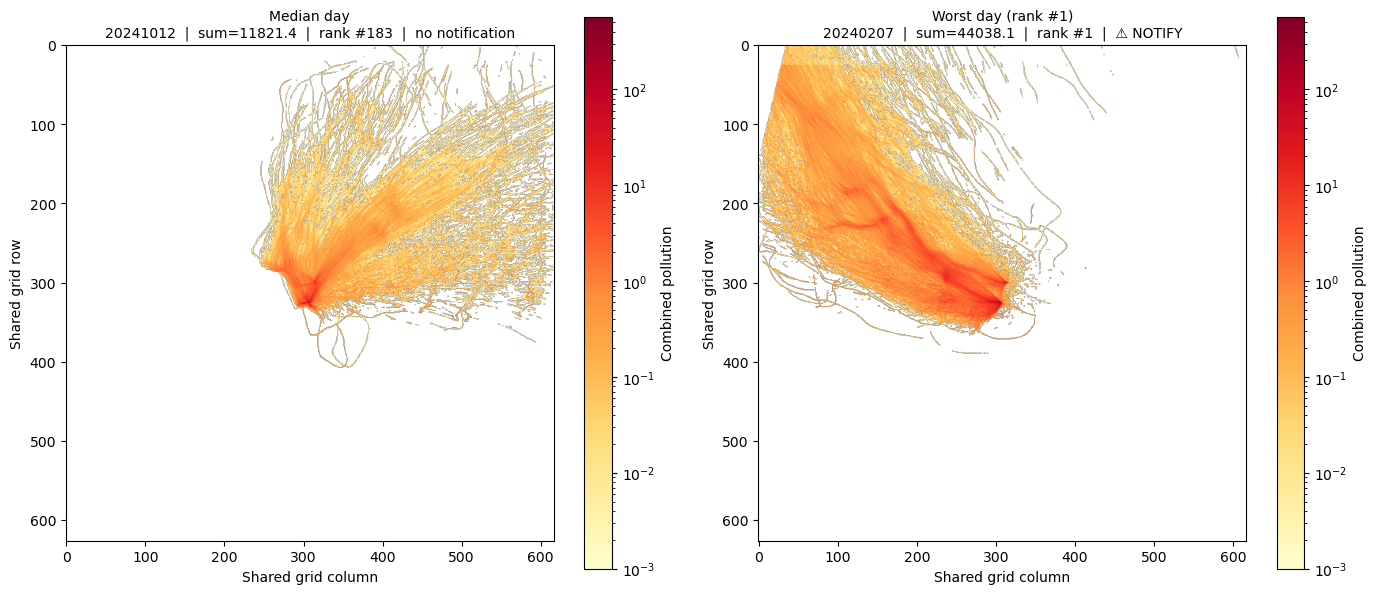

In [24]:
worst_date   = daily.sort_values('rank').iloc[0]['date_str']
typical_date = daily.sort_values('regional_sum').iloc[len(daily) // 2]['date_str']
global_vmax  = daily['regional_max'].max()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, date_str, label in zip(
    axes,
    [typical_date, worst_date],
    ['Median day', 'Worst day (rank #1)']
):
    arr, srcs = combine_facilities(
        date_str, FACILITY_DIRS, offsets, grid_infos, shared_height, shared_width
    )
    display = arr.astype(float)
    display[display == 0] = np.nan
    row = daily[daily['date_str'] == date_str].iloc[0]

    im = ax.imshow(
        display, origin='upper', cmap='YlOrRd',
        norm=mcolors.LogNorm(vmin=1e-3, vmax=global_vmax)
    )
    plt.colorbar(im, ax=ax, label='Combined pollution')
    notify_str = '⚠ NOTIFY' if row['notify'] else 'no notification'
    ax.set_title(
        f'{label}\n{date_str}  |  sum={row["regional_sum"]:.1f}  |  rank #{int(row["rank"])}  |  {notify_str}',
        fontsize=10
    )
    ax.set_xlabel('Shared grid column'); ax.set_ylabel('Shared grid row')

plt.tight_layout()
plt.savefig('worst_vs_typical.png', dpi=130, bbox_inches='tight')
plt.show()

If we decide to go with a more locale-specific notification, we should look into using max too!

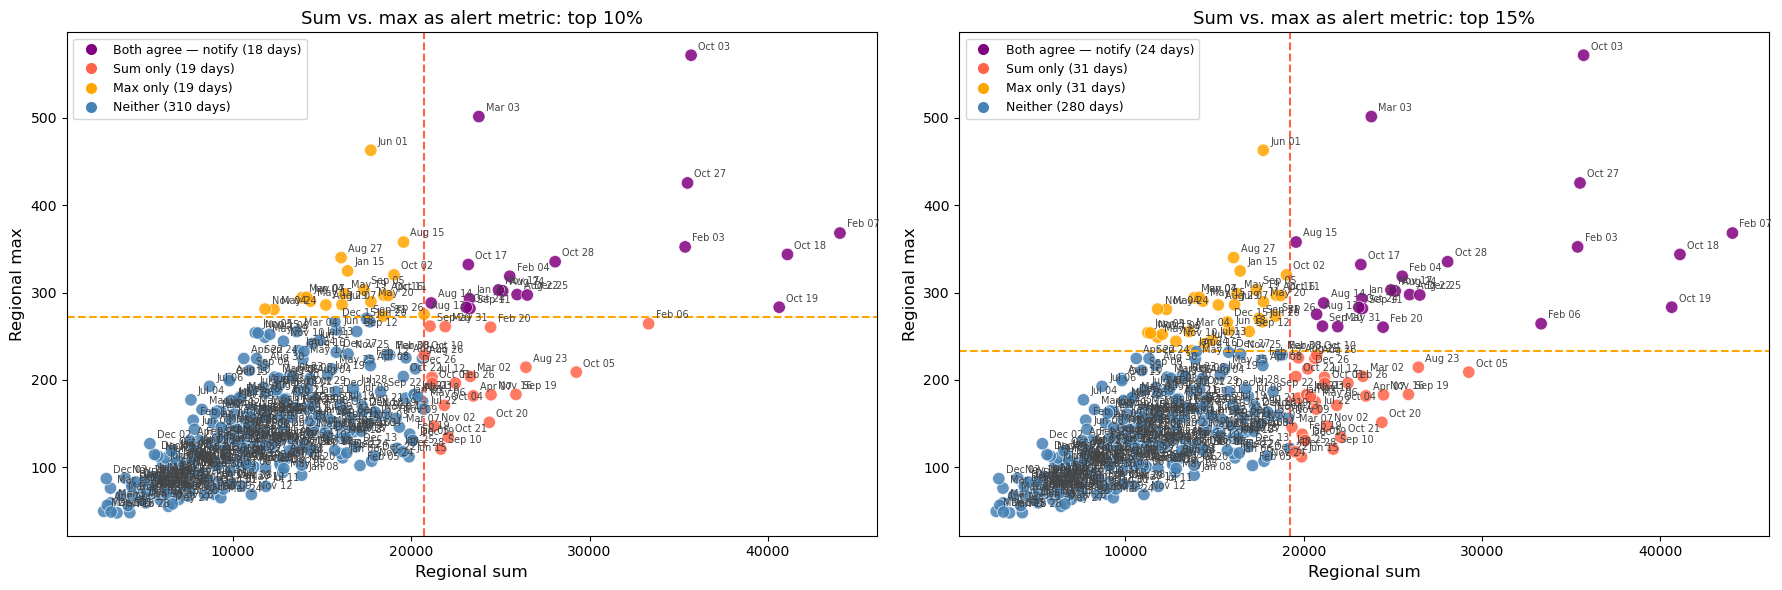

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, fraction in zip(axes, [0.10, 0.15]):
    threshold_sum = daily['regional_sum'].quantile(1 - fraction)
    threshold_max = daily['regional_max'].quantile(1 - fraction)
    
    notify_by_sum = daily['regional_sum'] >= threshold_sum
    notify_by_max = daily['regional_max'] >= threshold_max

    # Four categories of days
    both    = notify_by_sum & notify_by_max
    sum_only = notify_by_sum & ~notify_by_max
    max_only = ~notify_by_sum & notify_by_max
    neither = ~notify_by_sum & ~notify_by_max

    colors = np.where(both,     'purple',
             np.where(sum_only, 'tomato',
             np.where(max_only, 'orange', 'steelblue')))

    ax.scatter(daily['regional_sum'], daily['regional_max'],
               c=colors, s=80, alpha=0.85, edgecolors='white', linewidth=0.5)

    ax.axvline(threshold_sum, color='tomato',  linestyle='--', linewidth=1.5, label=f'Sum threshold')
    ax.axhline(threshold_max, color='orange',  linestyle='--', linewidth=1.5, label=f'Max threshold')

    # Label each point with its date
    for _, row in daily.iterrows():
        dt = pd.to_datetime(row['date_str'], format='%Y%m%d').strftime('%b %d')
        ax.annotate(dt, (row['regional_sum'], row['regional_max']),
                    textcoords='offset points', xytext=(5, 4), fontsize=7, color='#444')

    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0],[0], marker='o', color='w', markerfacecolor='purple', markersize=9,
               label=f'Both agree — notify ({both.sum()} days)'),
        Line2D([0],[0], marker='o', color='w', markerfacecolor='tomato', markersize=9,
               label=f'Sum only ({sum_only.sum()} days)'),
        Line2D([0],[0], marker='o', color='w', markerfacecolor='orange', markersize=9,
               label=f'Max only ({max_only.sum()} days)'),
        Line2D([0],[0], marker='o', color='w', markerfacecolor='steelblue', markersize=9,
               label=f'Neither ({neither.sum()} days)'),
    ]
    ax.legend(handles=legend_elements, fontsize=9, loc='upper left')
    ax.set_xlabel('Regional sum', fontsize=12)
    ax.set_ylabel('Regional max', fontsize=12)
    ax.set_title(f'Sum vs. max as alert metric: top {fraction*100:.0f}%', fontsize=13)
    ax.tick_params(labelsize=10)

plt.tight_layout()
plt.savefig('sum_vs_max_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

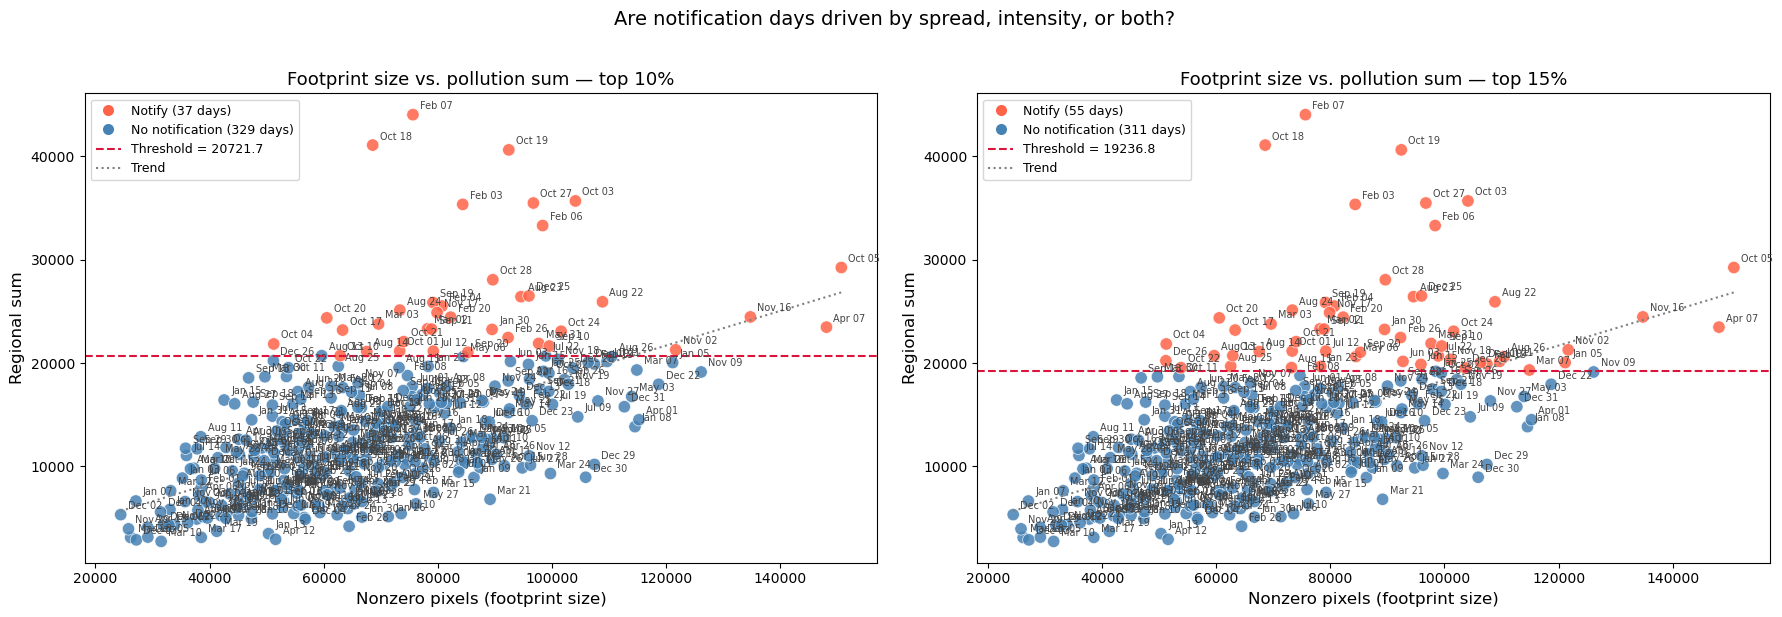

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, fraction in zip(axes, [0.10, 0.15]):
    threshold_sum = daily['regional_sum'].quantile(1 - fraction)
    notify = daily['regional_sum'] >= threshold_sum

    colors = ['tomato' if n else 'steelblue' for n in notify]

    ax.scatter(daily['nonzero_pixels'], daily['regional_sum'],
               c=colors, s=80, alpha=0.85, edgecolors='white', linewidth=0.5)

    # Label each point with its date
    for _, row in daily.iterrows():
        dt = pd.to_datetime(row['date_str'], format='%Y%m%d').strftime('%b %d')
        ax.annotate(dt, (row['nonzero_pixels'], row['regional_sum']),
                    textcoords='offset points', xytext=(5, 4), fontsize=7, color='#444')

    ax.axhline(threshold_sum, color='crimson', linestyle='--', linewidth=1.5,
               label=f'Notify threshold = {threshold_sum:.1f}')

    # Trend line
    z = np.polyfit(daily['nonzero_pixels'], daily['regional_sum'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(daily['nonzero_pixels'].min(), daily['nonzero_pixels'].max(), 100)
    ax.plot(x_line, p(x_line), color='grey', linestyle=':', linewidth=1.5, label='Trend')

    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0],[0], marker='o', color='w', markerfacecolor='tomato', markersize=9,
               label=f'Notify ({notify.sum()} days)'),
        Line2D([0],[0], marker='o', color='w', markerfacecolor='steelblue', markersize=9,
               label=f'No notification ({(~notify).sum()} days)'),
        Line2D([0],[0], color='crimson', linestyle='--', label=f'Threshold = {threshold_sum:.1f}'),
        Line2D([0],[0], color='grey',   linestyle=':',  label='Trend'),
    ]
    ax.legend(handles=legend_elements, fontsize=9, loc='upper left')
    ax.set_xlabel('Nonzero pixels (footprint size)', fontsize=12)
    ax.set_ylabel('Regional sum', fontsize=12)
    ax.set_title(f'Footprint size vs. pollution sum — top {fraction*100:.0f}%', fontsize=13)
    ax.tick_params(labelsize=10)

plt.suptitle('Are notification days driven by spread, intensity, or both?', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('footprint_vs_sum.png', dpi=150, bbox_inches='tight')
plt.show()

Not sure what to make of this... I thought maybe we'd see it clearly being related to depth/breadth but not sure it's clear enough to know.

## Notes

**Changing the threshold:** Update `TOP_FRACTION` and re-run from the *Apply notification threshold* cell.